# Cluster Analysis Based on Sentiment Label

This notebook performs a comprehensive cluster analysis examining the relationship between K-means clusters and sentiment labels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the clustered data
df = pd.read_csv('twitter_hdbscan_clustered.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (30889, 6)

First few rows:
       textID                                               text sentiment  \
0  cb774db0d1                I`d have responded, if I were going   neutral   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!  negative   
2  088c60f138                          my boss is bullying me...  negative   
3  9642c003ef                     what interview! leave me alone  negative   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...  negative   

                                            raw_text  \
0                I`d have responded, if I were going   
1      Sooo SAD I will miss you here in San Diego!!!   
2                          my boss is bullying me...   
3                     what interview! leave me alone   
4   Sons of ****, why couldn`t they put them on t...   

                                          clean_text  cluster  
0                i`d have responded, if i were going       32  
1      sooo sad i will 

## Sentiment Distribution

Sentiment distribution:
sentiment
neutral     12510
positive     9616
negative     8763
Name: count, dtype: int64

Percentage distribution:
sentiment
neutral     40.50
positive    31.13
negative    28.37
Name: count, dtype: float64


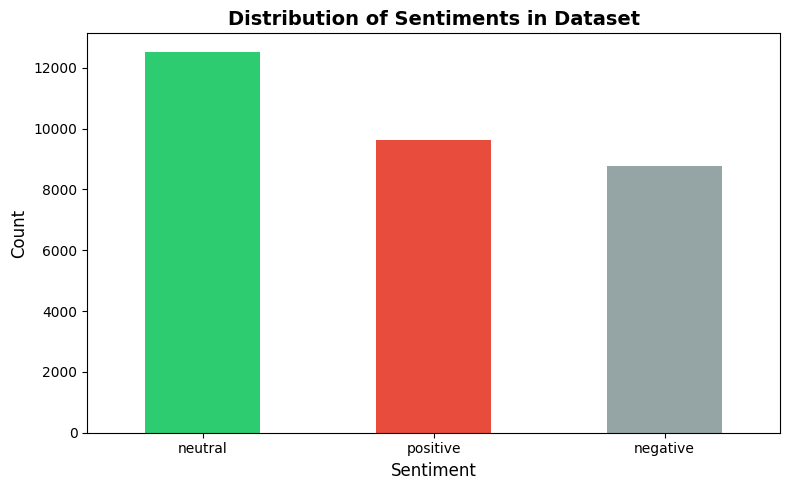

In [2]:
sentiment_counts = df['sentiment'].value_counts()
print("Sentiment distribution:")
print(sentiment_counts)
print(f"\nPercentage distribution:")
print((sentiment_counts / len(df) * 100).round(2))

# Visualize sentiment distribution
fig, ax = plt.subplots(figsize=(8, 5))
sentiment_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c', '#95a5a6'], ax=ax)
ax.set_title('Distribution of Sentiments in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Cluster Distribution

Total number of clusters: 34

Cluster distribution:
cluster
-1     16551
 0       941
 1       232
 2       134
 3       167
 4       287
 5       112
 6      1164
 7       830
 8       228
 9       150
 10      183
 11      466
 12      892
 13      227
 14      113
 15     1238
 16      932
 17      305
 18      876
 19      380
 20      574
 21      258
 22      154
 23      128
 24      106
 25      522
 26      662
 27      434
 28      665
 29      299
 30      204
 31      240
 32      235
Name: count, dtype: int64


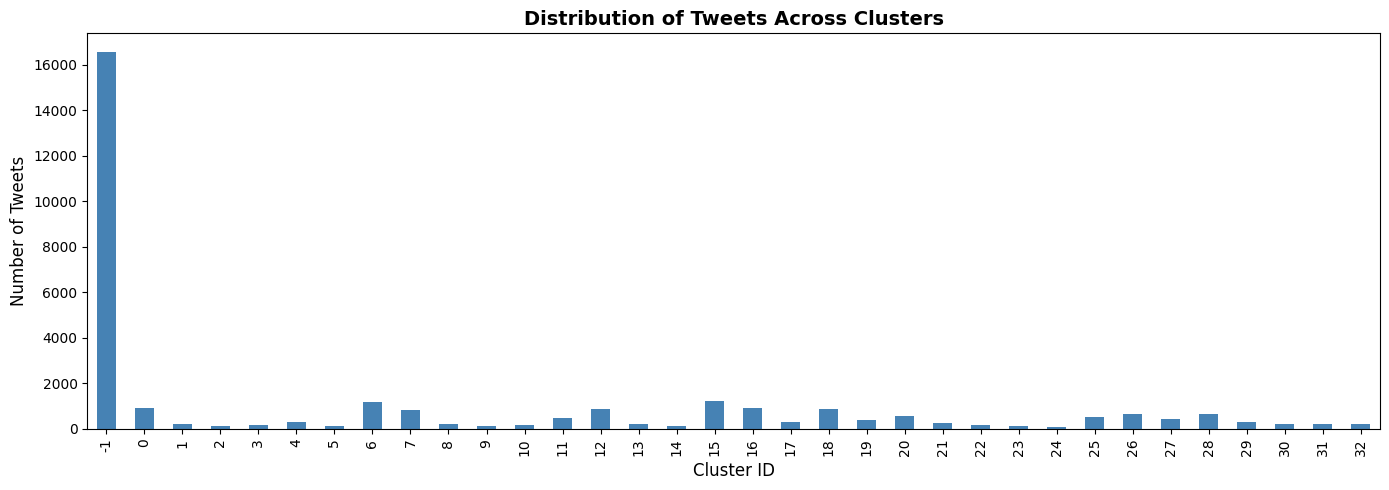

In [3]:
cluster_counts = df['cluster'].value_counts().sort_index()
print(f"Total number of clusters: {df['cluster'].nunique()}")
print(f"\nCluster distribution:")
print(cluster_counts)

# Visualize cluster distribution
fig, ax = plt.subplots(figsize=(14, 5))
cluster_counts.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Distribution of Tweets Across Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
plt.tight_layout()
plt.show()

## Cluster-Sentiment Cross Analysis

Examine the relationship between clusters and sentiment labels to understand which sentiment values are dominant in each cluster.

Cluster-Sentiment Cross Tabulation:
sentiment  negative  neutral  positive
cluster                               
-1             4393     7154      5004
 0               32      137       772
 1               35       77       120
 2               94       38         2
 3               35       76        56
 4               68      144        75
 5               43       51        18
 6              284      518       362
 7              280      340       210
 8              138       62        28
 9               55       72        23
 10              45       98        40
 11             207      180        79
 12             306      380       206
 13              48      101        78
 14               7       28        78
 15             830      275       133
 16             381      376       175
 17              49      128       128
 18             201      391       284
 19               3       32       345
 20             258      232        84
 21               2       62

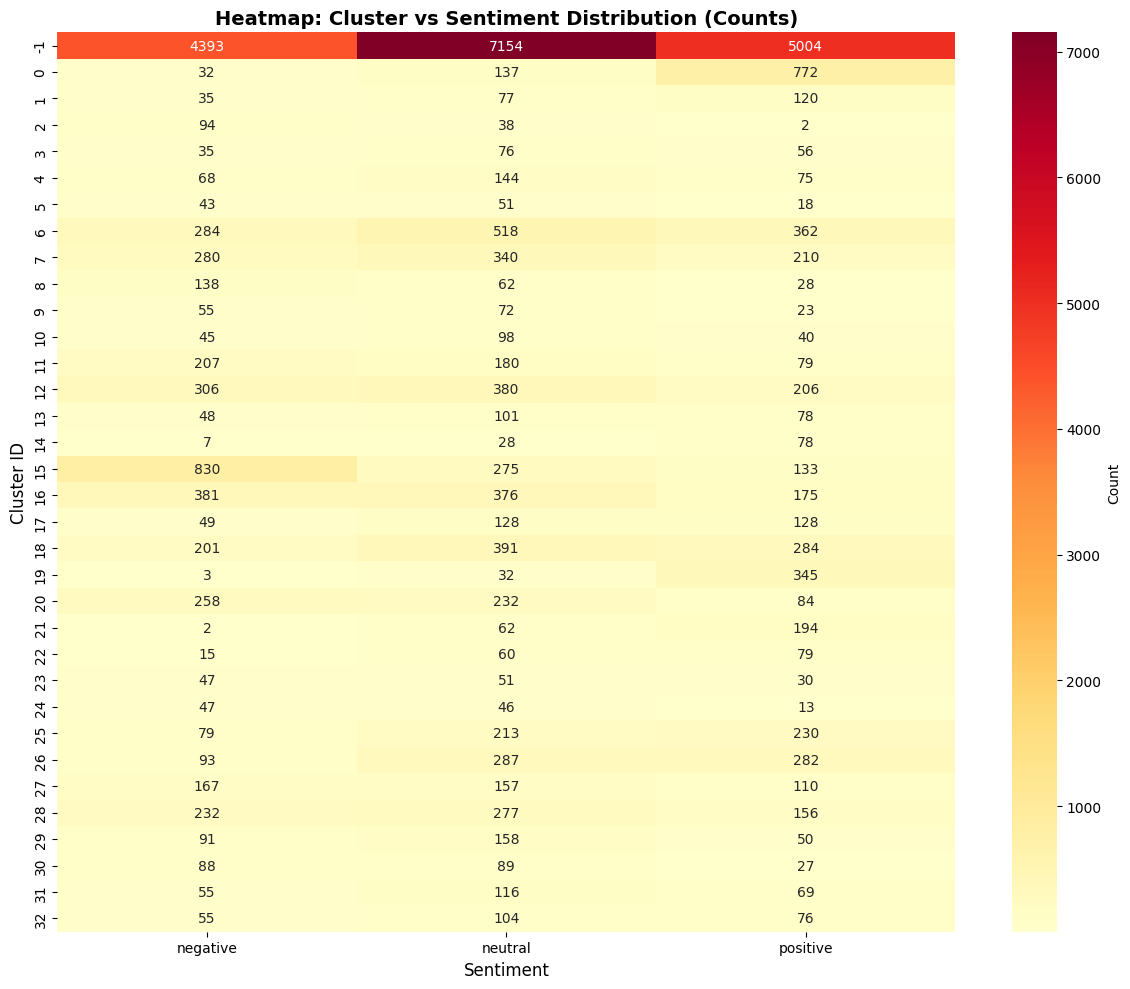

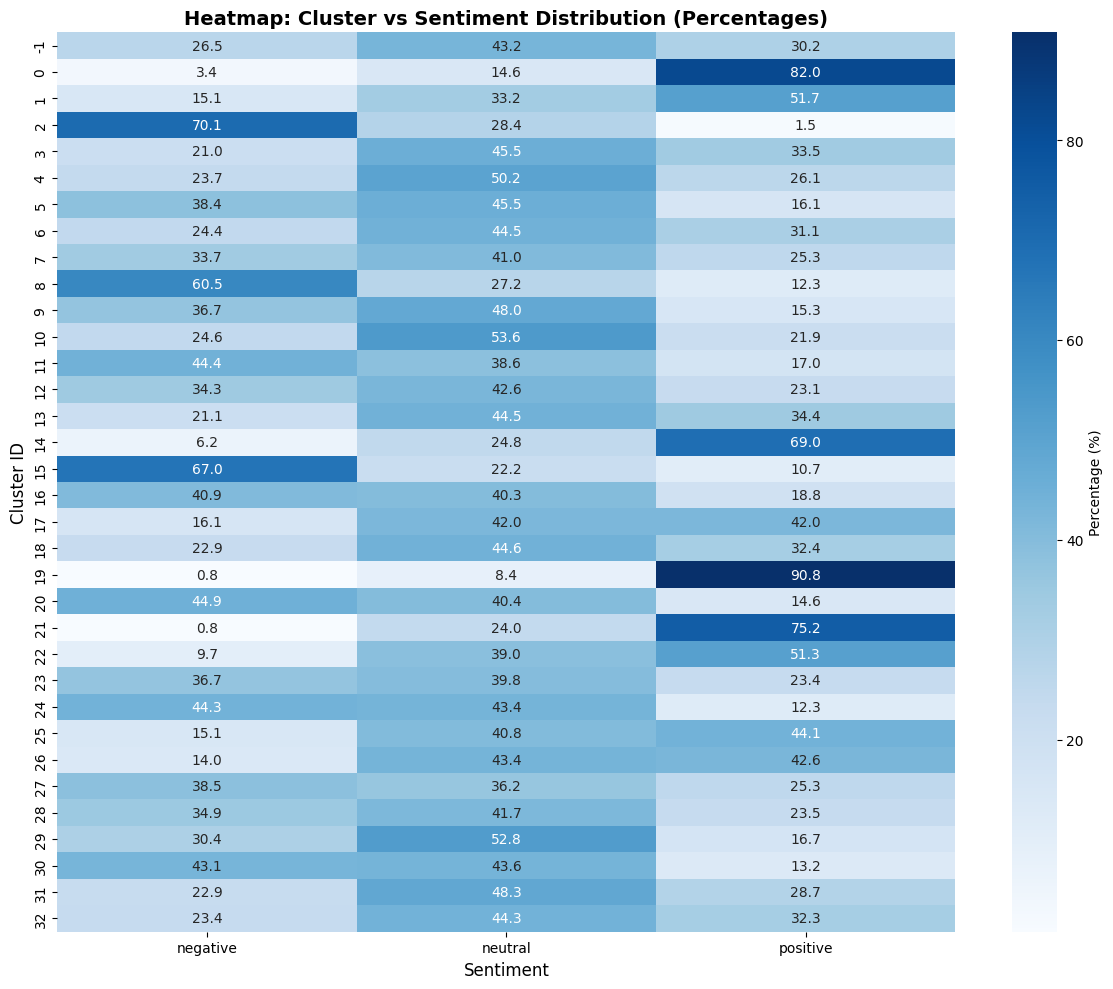

In [4]:
# Create cross-tabulation
crosstab = pd.crosstab(df['cluster'], df['sentiment'])
print("Cluster-Sentiment Cross Tabulation:")
print(crosstab)

# Calculate percentages for each cluster
crosstab_pct = pd.crosstab(df['cluster'], df['sentiment'], normalize='index') * 100
print("\n\nCluster-Sentiment Percentages (% within each cluster):")
print(crosstab_pct.round(2))

# Visualize as heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'}, ax=ax)
ax.set_title('Heatmap: Cluster vs Sentiment Distribution (Counts)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Cluster ID', fontsize=12)
plt.tight_layout()
plt.show()

# Heatmap with percentages
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Percentage (%)'}, ax=ax)
ax.set_title('Heatmap: Cluster vs Sentiment Distribution (Percentages)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Cluster ID', fontsize=12)
plt.tight_layout()
plt.show()

## Sentiment by Cluster Topic

Load topic labels for each cluster and visualize sentiment patterns by topic instead of cluster ID alone.

Cluster labels preview:
   cluster                         labels  size
0        0         Mother's Day greetings   941
1        1  Birthdays and birthday wishes   232
2        2        Boredom / nothing to do   134
3        3              Books and reading   167
4        4                    Sports talk   287


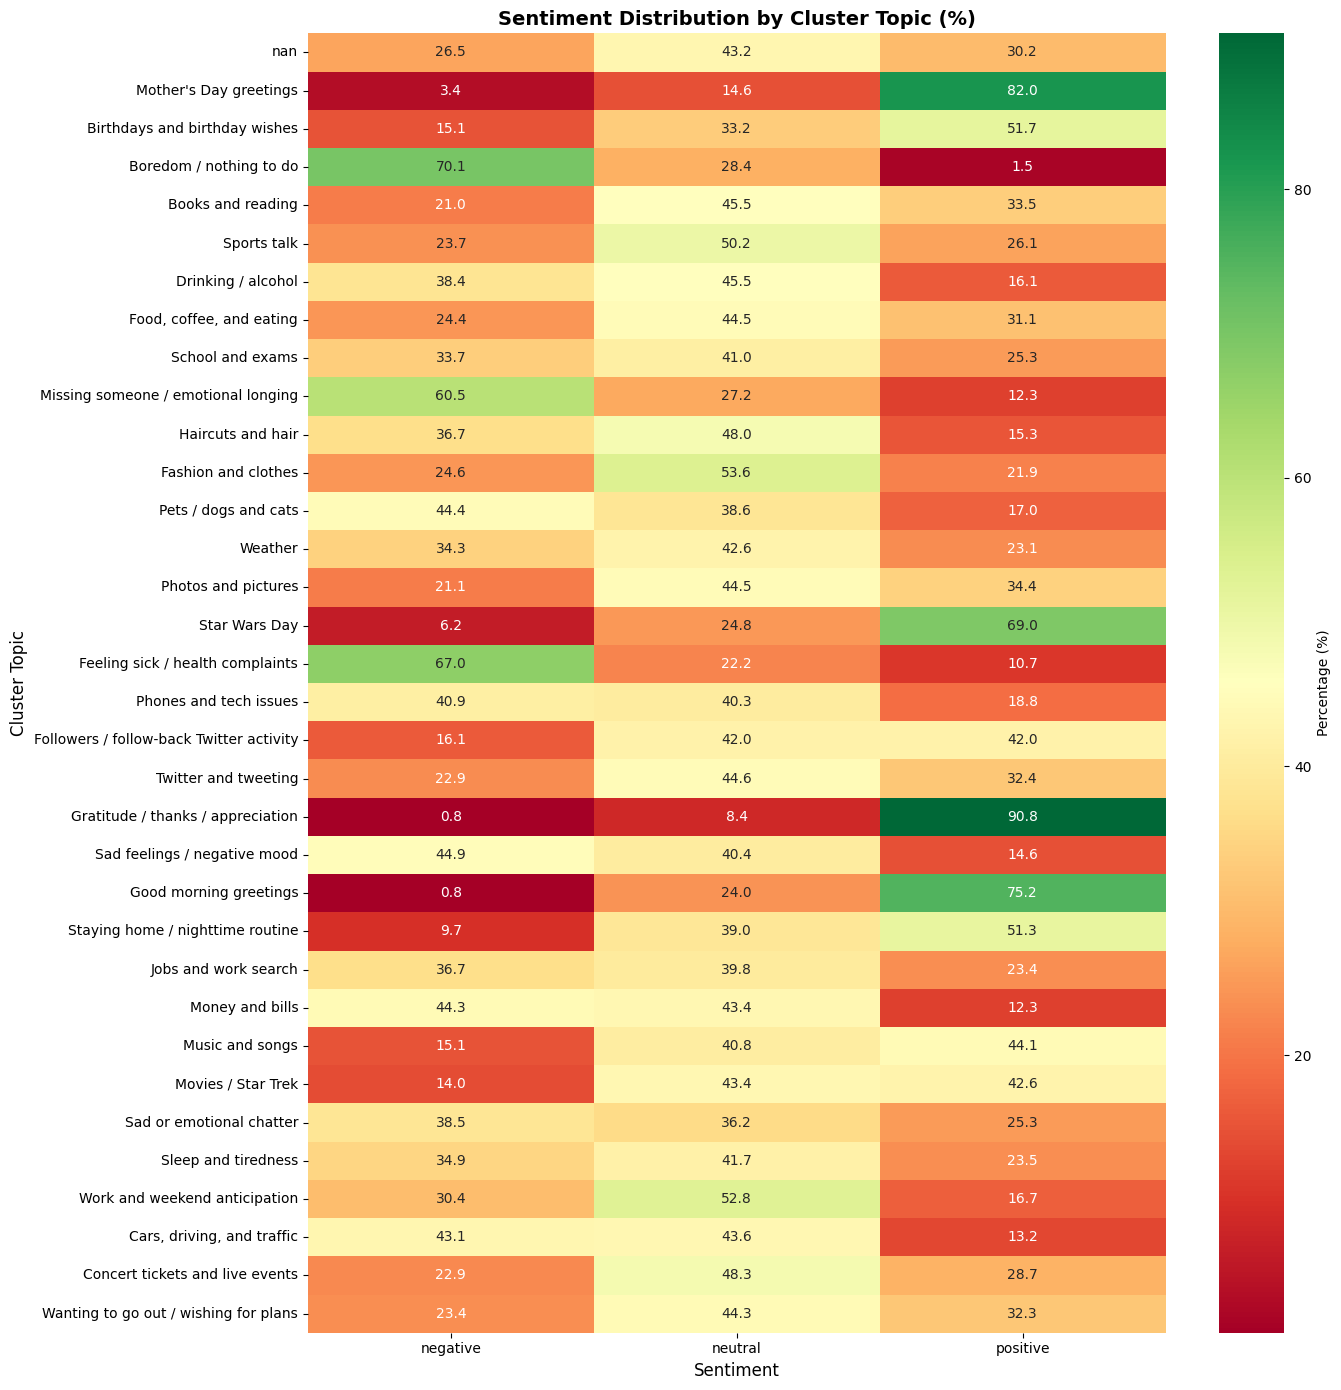

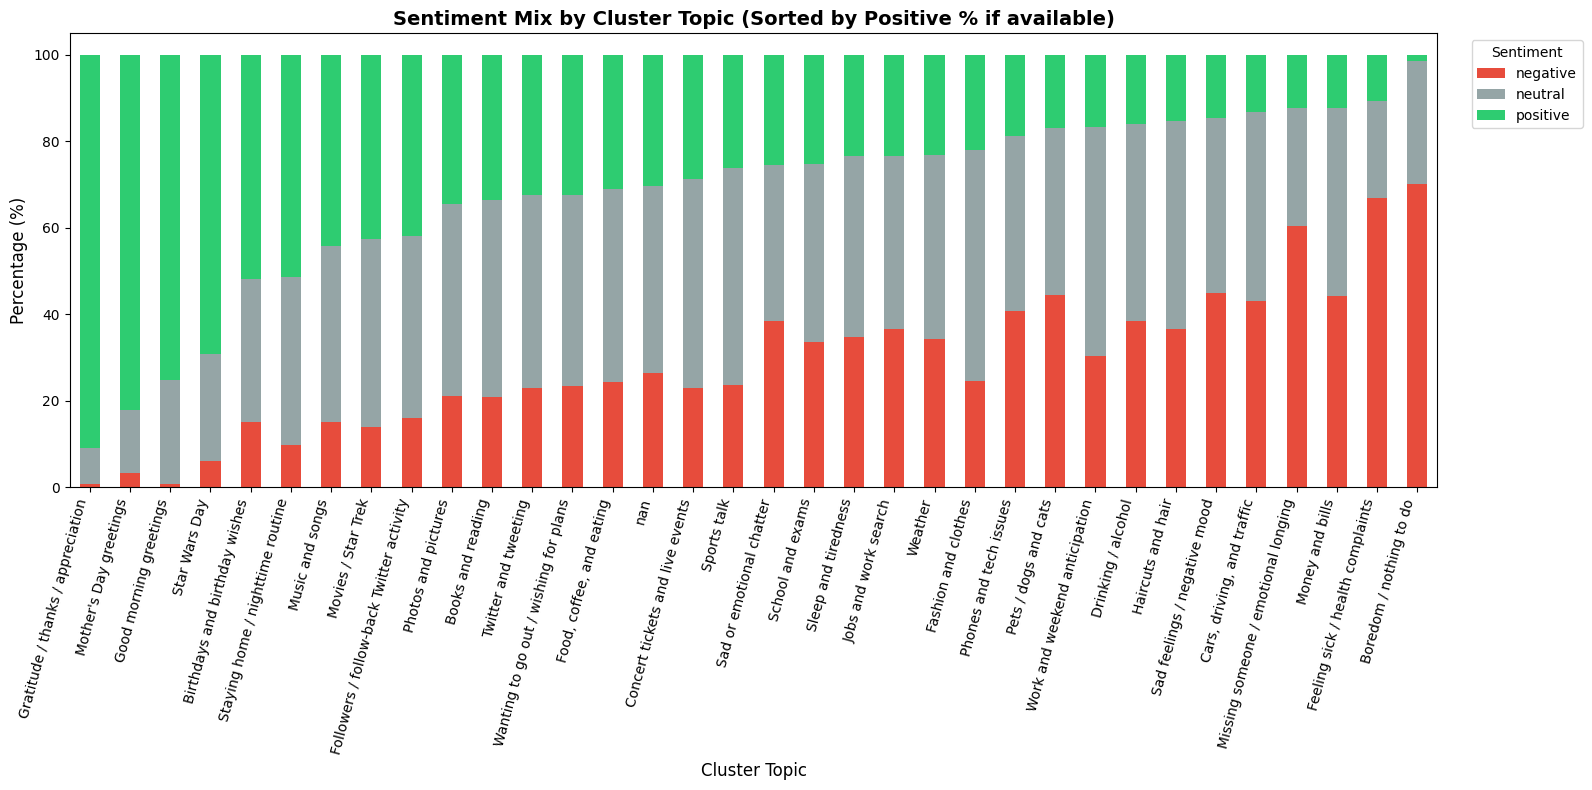

In [5]:
# Load topic labels for clusters
labels_df = pd.read_csv('twitter_hdbscan_cluster_labels.csv')
labels_df = labels_df[['cluster', 'labels', 'size']].sort_values('cluster')

print('Cluster labels preview:')
print(labels_df.head())

# Merge sentiment distributions with topic labels
topic_sentiment_counts = (
    crosstab.reset_index()
    .merge(labels_df[['cluster', 'labels']], on='cluster', how='left')
    .set_index('labels')
)

topic_sentiment_pct = (
    crosstab_pct.reset_index()
    .merge(labels_df[['cluster', 'labels']], on='cluster', how='left')
    .set_index('labels')
)

# Keep the sentiment columns only for plotting
sentiment_cols = [col for col in crosstab.columns if col in topic_sentiment_counts.columns]
topic_sentiment_counts = topic_sentiment_counts[sentiment_cols]
topic_sentiment_pct = topic_sentiment_pct[sentiment_cols]

# Heatmap: sentiment percentages by topic
fig, ax = plt.subplots(figsize=(14, 14))
sns.heatmap(
    topic_sentiment_pct,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Percentage (%)'},
    ax=ax
)
ax.set_title('Sentiment Distribution by Cluster Topic (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Cluster Topic', fontsize=12)
plt.tight_layout()
plt.show()

# Stacked bar chart sorted by likely-positive sentiment share when available
lower_col_map = {str(col).lower(): col for col in sentiment_cols}
sort_col = lower_col_map.get('positive', sentiment_cols[0])
sorted_topics = topic_sentiment_pct.sort_values(by=sort_col, ascending=False)

color_map = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral': '#95a5a6'
}
bar_colors = [color_map.get(str(col).lower(), '#3498db') for col in sentiment_cols]

fig, ax = plt.subplots(figsize=(16, 8))
sorted_topics.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=bar_colors
)
ax.set_title('Sentiment Mix by Cluster Topic (Sorted by Positive % if available)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster Topic', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Sample 20 random sentences from each cluster to validate cluster labels
SAMPLES_PER_CLUSTER = 20
RANDOM_SEED = 42

# Detect an available text column
candidate_text_cols = ['clean_text', 'text', 'tweet', 'tweet_text']
text_col = next((col for col in candidate_text_cols if col in df.columns), None)
if text_col is None:
    raise ValueError(f"None of the expected text columns were found: {candidate_text_cols}")

# Build a cluster -> label mapping when labels_df is available
cluster_to_label = {}
if 'labels_df' in globals() and {'cluster', 'labels'}.issubset(labels_df.columns):
    cluster_to_label = dict(labels_df[['cluster', 'labels']].drop_duplicates().values)

print(f"Using text column: {text_col}")
print(f"Random seed: {RANDOM_SEED}")
print("=" * 100)

for cluster_id in sorted(df['cluster'].dropna().unique()):
    cluster_id = int(cluster_id)
    cluster_rows = df[df['cluster'] == cluster_id][text_col].dropna().astype(str)
    cluster_rows = cluster_rows[cluster_rows.str.strip() != '']

    if len(cluster_rows) == 0:
        continue

    n_samples = min(SAMPLES_PER_CLUSTER, len(cluster_rows))
    sampled = cluster_rows.sample(n=n_samples, random_state=RANDOM_SEED, replace=False).tolist()

    label = cluster_to_label.get(cluster_id, 'N/A')
    print(f"\nCluster {cluster_id} | Label: {label} | Total rows: {len(cluster_rows)} | Showing: {n_samples}")
    print("-" * 100)

    for i, sentence in enumerate(sampled, start=1):
        print(f"{i:2d}. {sentence}")

Using text column: clean_text
Random seed: 42

Cluster -1 | Label: N/A | Total rows: 16551 | Showing: 20
----------------------------------------------------------------------------------------------------
 1. excited how the jon does will do today good luck guys ;)
 2. or he`s gonna chop you up into tiny bits - one of the two
 3. i`ve listed lots of new beads on ebay!
 4. not yet.... too early in the am
 5. no room for me smh
 6. you should tour!! *lol* i live all the way out in tennessee! :-p jk. how would you do that?
 7. _mom maybe people would start looking for us... like 'where`s waldo' but 'where`s the ckc'?
 8. so the movie was 3-d and really gooood
 9. 100,000 / 60 = 1667 words/day. 1667 / 10 = 167 words/hour. 167 / 60 = 2.8 words/minute. no pressure.
10. thanks for the shoutout
11. he always brightens up 'the week' ?
12. so tired. work today.
13. 50 kayla-lee, i think your the only one that knows what that number means lol x
14. late night...finally home.
15. the music in the

## Dominant Sentiment per Cluster

Identify the primary sentiment and its proportion in each cluster.

Dominant Sentiment per Cluster:
Cluster -1: neutral  ( 43.2%)
Cluster  0: positive ( 82.0%)
Cluster  1: positive ( 51.7%)
Cluster  2: negative ( 70.1%)
Cluster  3: neutral  ( 45.5%)
Cluster  4: neutral  ( 50.2%)
Cluster  5: neutral  ( 45.5%)
Cluster  6: neutral  ( 44.5%)
Cluster  7: neutral  ( 41.0%)
Cluster  8: negative ( 60.5%)
Cluster  9: neutral  ( 48.0%)
Cluster 10: neutral  ( 53.6%)
Cluster 11: negative ( 44.4%)
Cluster 12: neutral  ( 42.6%)
Cluster 13: neutral  ( 44.5%)
Cluster 14: positive ( 69.0%)
Cluster 15: negative ( 67.0%)
Cluster 16: negative ( 40.9%)
Cluster 17: positive ( 42.0%)
Cluster 18: neutral  ( 44.6%)
Cluster 19: positive ( 90.8%)
Cluster 20: negative ( 44.9%)
Cluster 21: positive ( 75.2%)
Cluster 22: positive ( 51.3%)
Cluster 23: neutral  ( 39.8%)
Cluster 24: negative ( 44.3%)
Cluster 25: positive ( 44.1%)
Cluster 26: neutral  ( 43.4%)
Cluster 27: negative ( 38.5%)
Cluster 28: neutral  ( 41.7%)
Cluster 29: neutral  ( 52.8%)
Cluster 30: neutral  ( 43.6%)
Cluster 

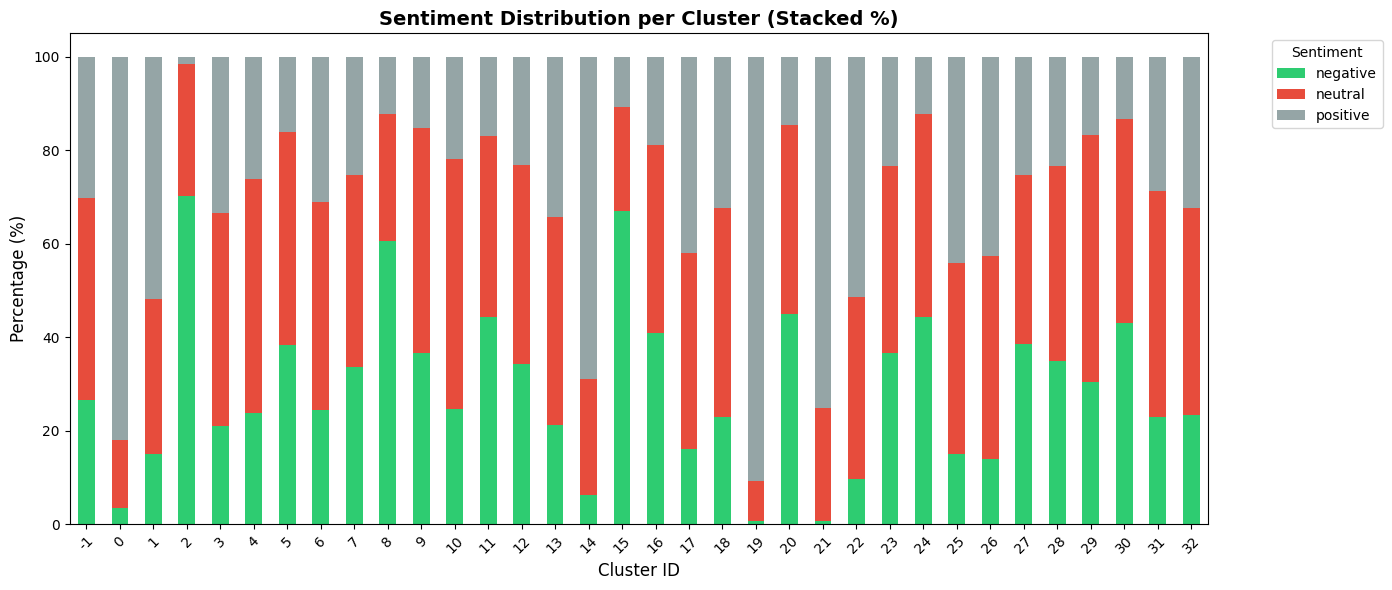

In [7]:
# Find dominant sentiment for each cluster
dominant_sentiment = {}
for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    dominant = cluster_data['sentiment'].value_counts().idxmax()
    proportion = cluster_data['sentiment'].value_counts().max() / len(cluster_data) * 100
    dominant_sentiment[cluster] = (dominant, proportion)

print("Dominant Sentiment per Cluster:")
print("=" * 60)
for cluster, (sentiment, proportion) in sorted(dominant_sentiment.items()):
    print(f"Cluster {cluster:2d}: {sentiment:8s} ({proportion:5.1f}%)")

# Create visualization: Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
crosstab_pct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_title('Sentiment Distribution per Cluster (Stacked %)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

## Statistical Summary

In [8]:
print("STATISTICAL SUMMARY")
print("=" * 60)
print(f"\nTotal number of tweets: {len(df):,}")
print(f"Total number of clusters: {df['cluster'].nunique()}")
print(f"\nSentiment Labels: {sorted(df['sentiment'].unique())}")
print(f"\nCluster size statistics:")
print(f"  Average cluster size: {df.groupby('cluster').size().mean():.1f}")
print(f"  Median cluster size: {df.groupby('cluster').size().median():.1f}")
print(f"  Min cluster size: {df.groupby('cluster').size().min()}")
print(f"  Max cluster size: {df.groupby('cluster').size().max()}")
print(f"  Std deviation: {df.groupby('cluster').size().std():.1f}")

# Diversity metric: How many different sentiments are in each cluster
print("\n\nSentiment diversity per cluster:")
sentiment_diversity = df.groupby('cluster')['sentiment'].nunique()
print(f"  Average number of distinct sentiments per cluster: {sentiment_diversity.mean():.2f}")
print(f"  Clusters with all 3 sentiments: {(sentiment_diversity == 3).sum()}")
print(f"  Clusters with 2 sentiments: {(sentiment_diversity == 2).sum()}")
print(f"  Clusters with 1 sentiment: {(sentiment_diversity == 1).sum()}")

# Purity metric for each cluster
print("\n\nCluster purity (max sentiment % in each cluster):")
cluster_purity = crosstab_pct.max(axis=1)
print(f"  Average cluster purity: {cluster_purity.mean():.2f}%")
print(f"  Min purity: {cluster_purity.min():.2f}% (Cluster {cluster_purity.idxmin()})")
print(f"  Max purity: {cluster_purity.max():.2f}% (Cluster {cluster_purity.idxmax()})")

STATISTICAL SUMMARY

Total number of tweets: 30,889
Total number of clusters: 34

Sentiment Labels: ['negative', 'neutral', 'positive']

Cluster size statistics:
  Average cluster size: 908.5
  Median cluster size: 293.0
  Min cluster size: 106
  Max cluster size: 16551
  Std deviation: 2783.2


Sentiment diversity per cluster:
  Average number of distinct sentiments per cluster: 3.00
  Clusters with all 3 sentiments: 34
  Clusters with 2 sentiments: 0
  Clusters with 1 sentiment: 0


Cluster purity (max sentiment % in each cluster):
  Average cluster purity: 51.00%
  Min purity: 38.48% (Cluster 27)
  Max purity: 90.79% (Cluster 19)


## Sample Tweets from Each Cluster

Display representative tweets from each cluster to understand cluster characteristics.

In [9]:
# Display sample tweets from clusters with dominant sentiments
print("SAMPLE TWEETS FROM SELECTED CLUSTERS")
print("=" * 80)

sample_clusters = sorted(df['cluster'].unique())[:5]  # Show first 5 clusters as examples

for cluster_id in sample_clusters:
    cluster_df = df[df['cluster'] == cluster_id]
    dominant, purity = dominant_sentiment[cluster_id]
    
    print(f"\n\nCluster {cluster_id} (Dominant sentiment: {dominant.upper()} - {purity:.1f}%)")
    print("-" * 80)
    print(f"Size: {len(cluster_df)} tweets")
    print(f"Sentiment breakdown: {dict(cluster_df['sentiment'].value_counts())}")
    print("\nSample tweets:")
    
    for idx, (_, row) in enumerate(cluster_df.head(3).iterrows(), 1):
        print(f"\n  {idx}. [{row['sentiment'].upper()}] {row['clean_text'][:100]}")
        if len(row['clean_text']) > 100:
            print(f"     {row['clean_text'][100:][:100]}...")  

SAMPLE TWEETS FROM SELECTED CLUSTERS


Cluster -1 (Dominant sentiment: NEUTRAL - 43.2%)
--------------------------------------------------------------------------------
Size: 16551 tweets
Sentiment breakdown: {'neutral': np.int64(7154), 'positive': np.int64(5004), 'negative': np.int64(4393)}

Sample tweets:

  1. [NEGATIVE] my boss is bullying me...

  2. [NEGATIVE] what interview! leave me alone

  3. [NEGATIVE] sons of ****, why couldn`t they put them on the releases we already bought


Cluster 0 (Dominant sentiment: POSITIVE - 82.0%)
--------------------------------------------------------------------------------
Size: 941 tweets
Sentiment breakdown: {'positive': np.int64(772), 'neutral': np.int64(137), 'negative': np.int64(32)}

Sample tweets:

  1. [POSITIVE] what better way to spoil mum than to let her kick back and relax over a nice meal and a bottle of he
     r favorite wine? our wine was a red...

  2. [POSITIVE] happy mothers day to all you mums out there

  3. [POSITIVE] ni

## Key Insights

**Cluster Quality Analysis: How well do clusters separate by sentiment?**

In [10]:
# Categorize clusters by their sentiment homogeneity
pure_clusters = []      # > 70% single sentiment
mixed_clusters = []     # 40-70% dominance
diverse_clusters = []   # < 40% dominance (more evenly distributed)

for cluster in sorted(df['cluster'].unique()):
    purity = cluster_purity[cluster]
    if purity > 70:
        pure_clusters.append(cluster)
    elif purity >= 40:
        mixed_clusters.append(cluster)
    else:
        diverse_clusters.append(cluster)

print(f"\nCluster Classification by Sentiment Homogeneity:")
print(f"  Pure clusters (>70% single sentiment): {len(pure_clusters)} clusters")
print(f"    Cluster IDs: {pure_clusters[:10]}{'...' if len(pure_clusters) > 10 else ''}")
print(f"\n  Mixed clusters (40-70% dominance): {len(mixed_clusters)} clusters")
print(f"    Cluster IDs: {mixed_clusters[:10]}{'...' if len(mixed_clusters) > 10 else ''}")
print(f"\n  Diverse clusters (<40% single sentiment): {len(diverse_clusters)} clusters")
print(f"    Cluster IDs: {diverse_clusters[:10]}{'...' if len(diverse_clusters) > 10 else ''}")

# Overall clustering quality
print(f"\n\nOverall Clustering Assessment:")
purity_score = cluster_purity.mean()
print(f"  ✓ Average cluster purity: {purity_score:.2f}%")
if purity_score > 70:
    print(f"    → Excellent: Clusters align well with sentiment labels")
elif purity_score > 50:
    print(f"    → Good: Reasonable sentiment-cluster alignment")
else:
    print(f"    → Fair: Mixed sentiment distribution across clusters")

# Sentiment distribution insights
print(f"\n{'Sentiment Distribution Insights:':}")
for sentiment in sorted(df['sentiment'].unique()):
    sentiment_df = df[df['sentiment'] == sentiment]
    num_clusters = sentiment_df['cluster'].nunique()
    concentration = sentiment_df['cluster'].value_counts().max() / len(sentiment_df) * 100
    print(f"  • {sentiment.capitalize():8s}: Found in {num_clusters:2d} clusters, "
          f"with {concentration:.1f}% concentrated in top cluster")


Cluster Classification by Sentiment Homogeneity:
  Pure clusters (>70% single sentiment): 4 clusters
    Cluster IDs: [np.int64(0), np.int64(2), np.int64(19), np.int64(21)]

  Mixed clusters (40-70% dominance): 28 clusters
    Cluster IDs: [np.int64(-1), np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]...

  Diverse clusters (<40% single sentiment): 2 clusters
    Cluster IDs: [np.int64(23), np.int64(27)]


Overall Clustering Assessment:
  ✓ Average cluster purity: 51.00%
    → Good: Reasonable sentiment-cluster alignment

Sentiment Distribution Insights:
  • Negative: Found in 34 clusters, with 50.1% concentrated in top cluster
  • Neutral : Found in 34 clusters, with 57.2% concentrated in top cluster
  • Positive: Found in 34 clusters, with 52.0% concentrated in top cluster
